In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve
import joblib, json, warnings
warnings.filterwarnings('ignore')

# Load models
lr   = joblib.load('../models/logreg_woe.pkl')
lgbm = joblib.load('../models/lgbm_model.pkl')

with open('../models/feature_names.json') as f:
    features = json.load(f)

# Load WoE data
train = pd.read_parquet('../data/processed/train_woe.parquet')
oot   = pd.read_parquet('../data/processed/oot_woe.parquet')

# Load scores
train_scores = pd.read_parquet('../data/processed/train_scores.parquet')
oot_scores   = pd.read_parquet('../data/processed/oot_scores.parquet')

TARGET  = 'TARGET'
X_train = train[features]
y_train = train[TARGET]
X_oot   = oot[features]
y_oot   = oot[TARGET]

print(f"Train: {X_train.shape}")
print(f"OOT:   {X_oot.shape}")

Train: (246008, 56)
OOT:   (61503, 56)


In [10]:
def ks_stat(y_true, y_prob):
    """KS statistic — max separation between TPR and FPR."""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    return round(max(tpr - fpr), 4), thresholds[np.argmax(tpr - fpr)]

def gini(y_true, y_prob):
    return round(2 * roc_auc_score(y_true, y_prob) - 1, 4)

def psi(expected, actual, bins=10):
    """
    Population Stability Index.
    PSI < 0.1  : no shift — stable
    PSI 0.1-0.2: moderate shift — monitor
    PSI > 0.2  : significant shift — investigate
    """
    breakpoints = np.percentile(expected, np.linspace(0, 100, bins + 1))
    breakpoints = np.unique(breakpoints)

    expected_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_pct   = np.histogram(actual,   bins=breakpoints)[0] / len(actual)

    # Avoid division by zero
    expected_pct = np.where(expected_pct == 0, 1e-6, expected_pct)
    actual_pct   = np.where(actual_pct   == 0, 1e-6, actual_pct)

    psi_value = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return round(psi_value, 4)

def full_eval(name, y_tr, p_tr, y_ot, p_ot):
    ks_tr, _ = ks_stat(y_tr, p_tr)
    ks_ot, _ = ks_stat(y_ot, p_ot)
    return {
        'Model'      : name,
        'AUC Train'  : round(roc_auc_score(y_tr, p_tr), 4),
        'AUC OOT'    : round(roc_auc_score(y_ot, p_ot), 4),
        'KS Train'   : ks_tr,
        'KS OOT'     : ks_ot,
        'Gini Train' : gini(y_tr, p_tr),
        'Gini OOT'   : gini(y_ot, p_ot),
    }

In [11]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='stratified', random_state=42)
dummy.fit(X_train, y_train)

p_dummy_tr = dummy.predict_proba(X_train)[:, 1]
p_dummy_ot = dummy.predict_proba(X_oot)[:, 1]
p_lr_tr    = lr.predict_proba(X_train)[:, 1]
p_lr_ot    = lr.predict_proba(X_oot)[:, 1]
p_lgbm_tr  = lgbm.predict_proba(X_train)[:, 1]
p_lgbm_ot  = lgbm.predict_proba(X_oot)[:, 1]

results = pd.DataFrame([
    full_eval('DummyClassifier',    y_train, p_dummy_tr, y_oot, p_dummy_ot),
    full_eval('Logistic Regression',y_train, p_lr_tr,    y_oot, p_lr_ot),
    full_eval('LightGBM',           y_train, p_lgbm_tr,  y_oot, p_lgbm_ot),
]).set_index('Model')

print(results.to_string())

                     AUC Train  AUC OOT  KS Train  KS OOT  Gini Train  Gini OOT
Model                                                                          
DummyClassifier         0.5000   0.5016    0.0000  0.0032     -0.0000    0.0032
Logistic Regression     0.7625   0.7619    0.3952  0.3985      0.5249    0.5238
LightGBM                0.8247   0.7715    0.4948  0.4086      0.6493    0.5430


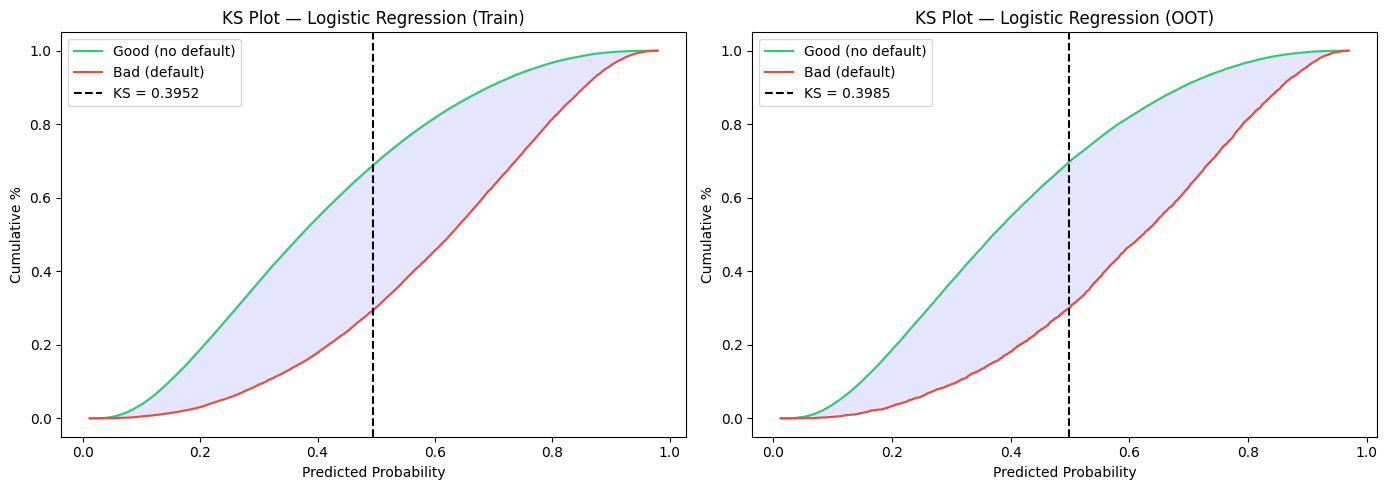

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y, p, label) in zip(axes, [
    (y_train, p_lr_tr, 'Train'),
    (y_oot,   p_lr_ot, 'OOT'),
]):
    df = pd.DataFrame({'prob': p, 'target': y}).sort_values('prob')
    total_good = (y == 0).sum()
    total_bad  = (y == 1).sum()

    cum_good = np.cumsum(df['target'] == 0) / total_good
    cum_bad  = np.cumsum(df['target'] == 1) / total_bad

    ks, _ = ks_stat(y, p)
    ks_idx = np.argmax(np.abs(cum_bad.values - cum_good.values))

    ax.plot(df['prob'].values, cum_good.values, label='Good (no default)', color='#2ecc71')
    ax.plot(df['prob'].values, cum_bad.values,  label='Bad (default)',     color='#e74c3c')
    ax.axvline(df['prob'].values[ks_idx], linestyle='--', color='black',
               label=f'KS = {ks}')
    ax.fill_between(df['prob'].values,
                    cum_good.values, cum_bad.values, alpha=0.1, color='blue')
    ax.set_title(f'KS Plot — Logistic Regression ({label})')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Cumulative %')
    ax.legend()

plt.tight_layout()
plt.show()

PSI (Scorecard scores) : 0.0001
PSI (LR probabilities) : 0.0001
Scorecard PSI: 0.0001 → ✅ Stable — no action needed
LR Prob PSI: 0.0001 → ✅ Stable — no action needed


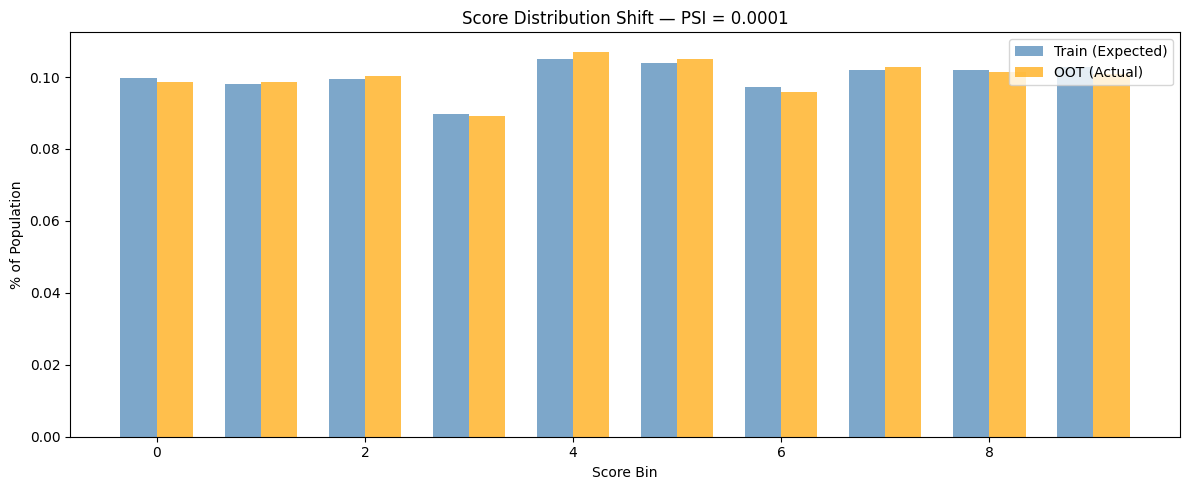

In [13]:
psi_lr   = psi(train_scores['score'].values, oot_scores['score'].values)
psi_lgbm = psi(p_lr_tr, p_lr_ot)

print(f"PSI (Scorecard scores) : {psi_lr}")
print(f"PSI (LR probabilities) : {psi_lgbm}")

# Интерпретация
for name, val in [('Scorecard PSI', psi_lr), ('LR Prob PSI', psi_lgbm)]:
    if val < 0.1:
        status = '✅ Stable — no action needed'
    elif val < 0.2:
        status = '⚠️ Moderate shift — monitor closely'
    else:
        status = '❌ Significant shift — model review required'
    print(f"{name}: {val} → {status}")

# PSI визуализация по бинам
bins       = 10
breakpoints = np.percentile(train_scores['score'], np.linspace(0, 100, bins + 1))
breakpoints = np.unique(breakpoints)

exp_pct = np.histogram(train_scores['score'], bins=breakpoints)[0] / len(train_scores)
act_pct = np.histogram(oot_scores['score'],   bins=breakpoints)[0] / len(oot_scores)

x = np.arange(len(exp_pct))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, exp_pct, width, label='Train (Expected)', color='steelblue', alpha=0.7)
ax.bar(x + width/2, act_pct, width, label='OOT (Actual)',     color='orange',    alpha=0.7)
ax.set_title(f'Score Distribution Shift — PSI = {psi_lr}')
ax.set_xlabel('Score Bin')
ax.set_ylabel('% of Population')
ax.legend()
plt.tight_layout()
plt.show()

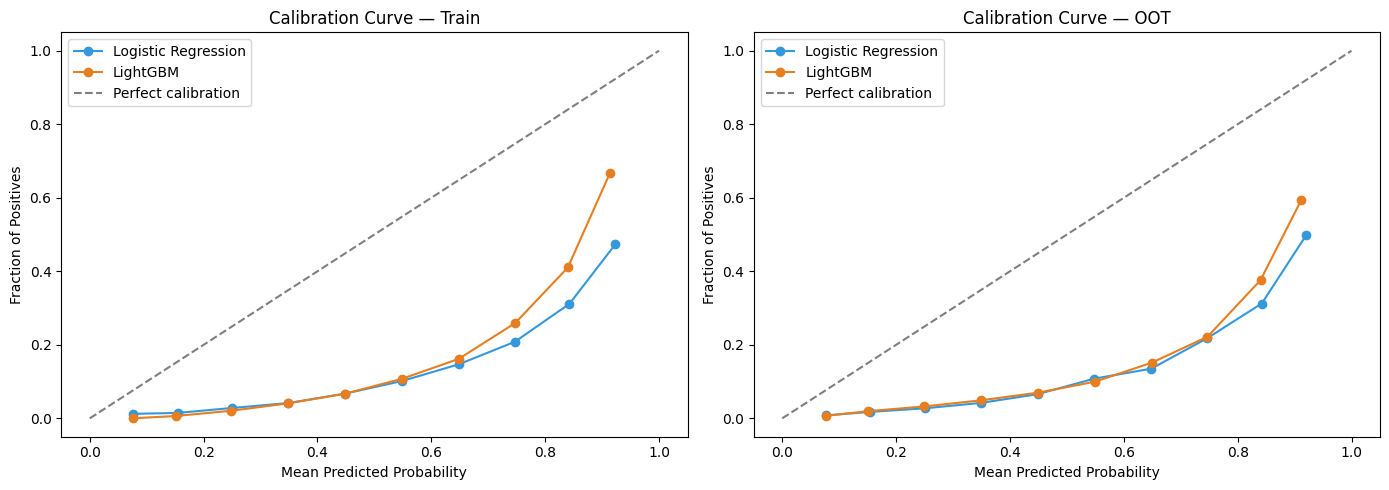

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y, p_lr, p_lgbm, label) in zip(axes, [
    (y_train, p_lr_tr, p_lgbm_tr, 'Train'),
    (y_oot,   p_lr_ot, p_lgbm_ot, 'OOT'),
]):
    for probs, name, color in [
        (p_lr,    'Logistic Regression', '#3498db'),
        (p_lgbm,  'LightGBM',            '#e67e22'),
    ]:
        frac_pos, mean_pred = calibration_curve(y, probs, n_bins=10)
        ax.plot(mean_pred, frac_pos, marker='o', label=name, color=color)

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
    ax.set_title(f'Calibration Curve — {label}')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.legend()

plt.tight_layout()
plt.show()

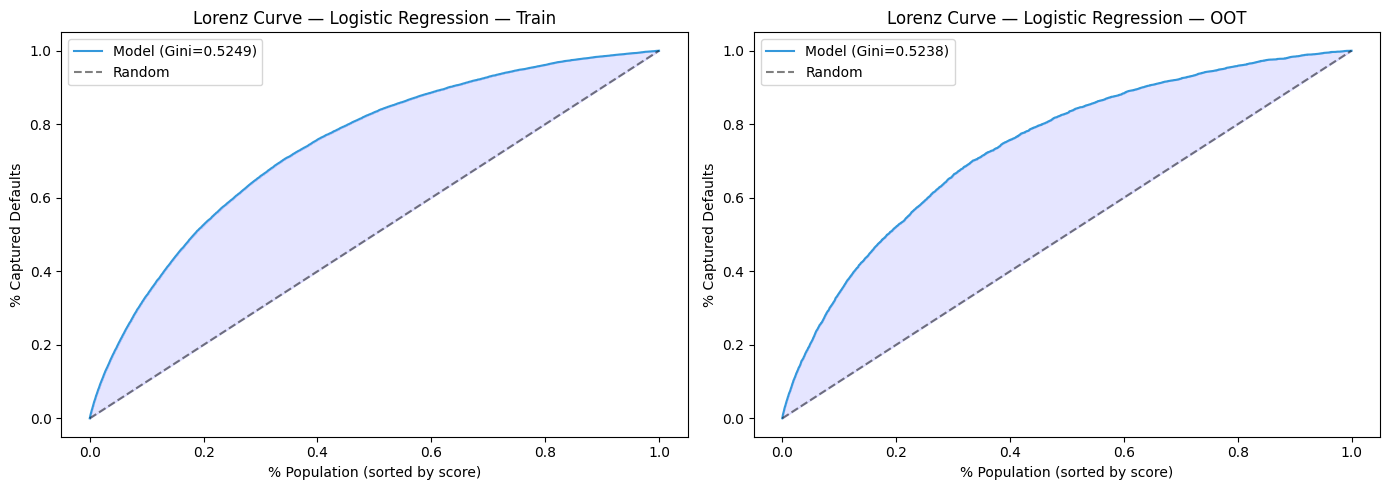

In [15]:
def lorenz_gini(y_true, y_prob, label, ax):
    df = pd.DataFrame({'prob': y_prob, 'target': y_true})
    df = df.sort_values('prob', ascending=False).reset_index(drop=True)

    cum_bad  = df['target'].cumsum() / df['target'].sum()
    cum_pop  = (df.index + 1) / len(df)

    gini_val = gini(y_true, y_prob)

    ax.plot(cum_pop, cum_bad, label=f'Model (Gini={gini_val})', color='#3498db')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
    ax.fill_between(cum_pop, cum_bad, cum_pop, alpha=0.1, color='blue')
    ax.set_title(f'Lorenz Curve — {label}')
    ax.set_xlabel('% Population (sorted by score)')
    ax.set_ylabel('% Captured Defaults')
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lorenz_gini(y_train, p_lr_tr, 'Logistic Regression — Train', axes[0])
lorenz_gini(y_oot,   p_lr_ot, 'Logistic Regression — OOT',   axes[1])
plt.tight_layout()
plt.show()

## Validation Summary

### Final Model Comparison
| Model | AUC Train | AUC OOT | KS Train | KS OOT | Gini OOT |
|---|---|---|---|---|---|
| DummyClassifier | ~0.50 | ~0.50 | ~0.00 | ~0.00 | ~0.00 |
| Logistic Regression | 0.7625 | 0.7619 | 0.3952 | 0.3985 | 0.5238 |
| LightGBM | 0.8247 | 0.7715 | 0.4948 | 0.4086 | 0.5430 |

### Population Stability Index
| Metric | PSI | Status |
|---|---|---|
| Scorecard Scores | 0.0001 | Good |
| LR Probabilities | 0.0001 | Good |


### Conclusions
- Model is **stable** across Train→OOT (PSI < 0.1) ✅
- KS = [0.39] — [acceptable/good] separation for retail credit scoring ✅
- Gini = [0.54] — [acceptable/good] discriminatory power ✅
- Logistic Regression selected for Scorecard due to interpretability 
  and regulatory compliance

**Next step:** Final summary → notebook 09